In [48]:
import copy
import json
import scipy as sp
import statsmodels.api as sm
import sympy as sym
import pooch
import os
from pathlib import Path
import gdown
import seaborn as sns
import anndata as ad
import torch
import scgpt as scg
from scgpt.tasks import GeneEmbedding
from scgpt.tokenizer.gene_tokenizer import GeneVocab
from scgpt.model import TransformerModel
from scgpt.preprocess import Preprocessor
from scgpt.utils import set_seed
import numpy as np
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.colors import Normalize
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
import matplotlib.ticker as mticker

In [49]:
# --- output location ---
plots_dir = Path("./plots")
plots_dir.mkdir(exist_ok=True)

In [50]:
adata = sc.read_h5ad("data/adata_embedded.h5ad")
X = adata.X.toarray() if hasattr(adata.X, "toarray") else adata.X
print(np.isnan(X).sum(), "NaNs across", X.shape)

0 NaNs across (49444, 1916)


In [51]:
#UMAP for scGPT
sc.pp.neighbors(adata, use_rep="X_scGPT", key_added="scgpt")
sc.tl.umap(adata, neighbors_key="scgpt")
adata.obsm["X_umap_scgpt"] = adata.obsm.pop("X_umap")

/var/folders/y3/x0z5n17j1dj0d6ns5vgwbk600000gn/T/ipykernel_2418/1982665695.py:7: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not pd.api.types.is_categorical_dtype(adata.obs[cell_type_key]):


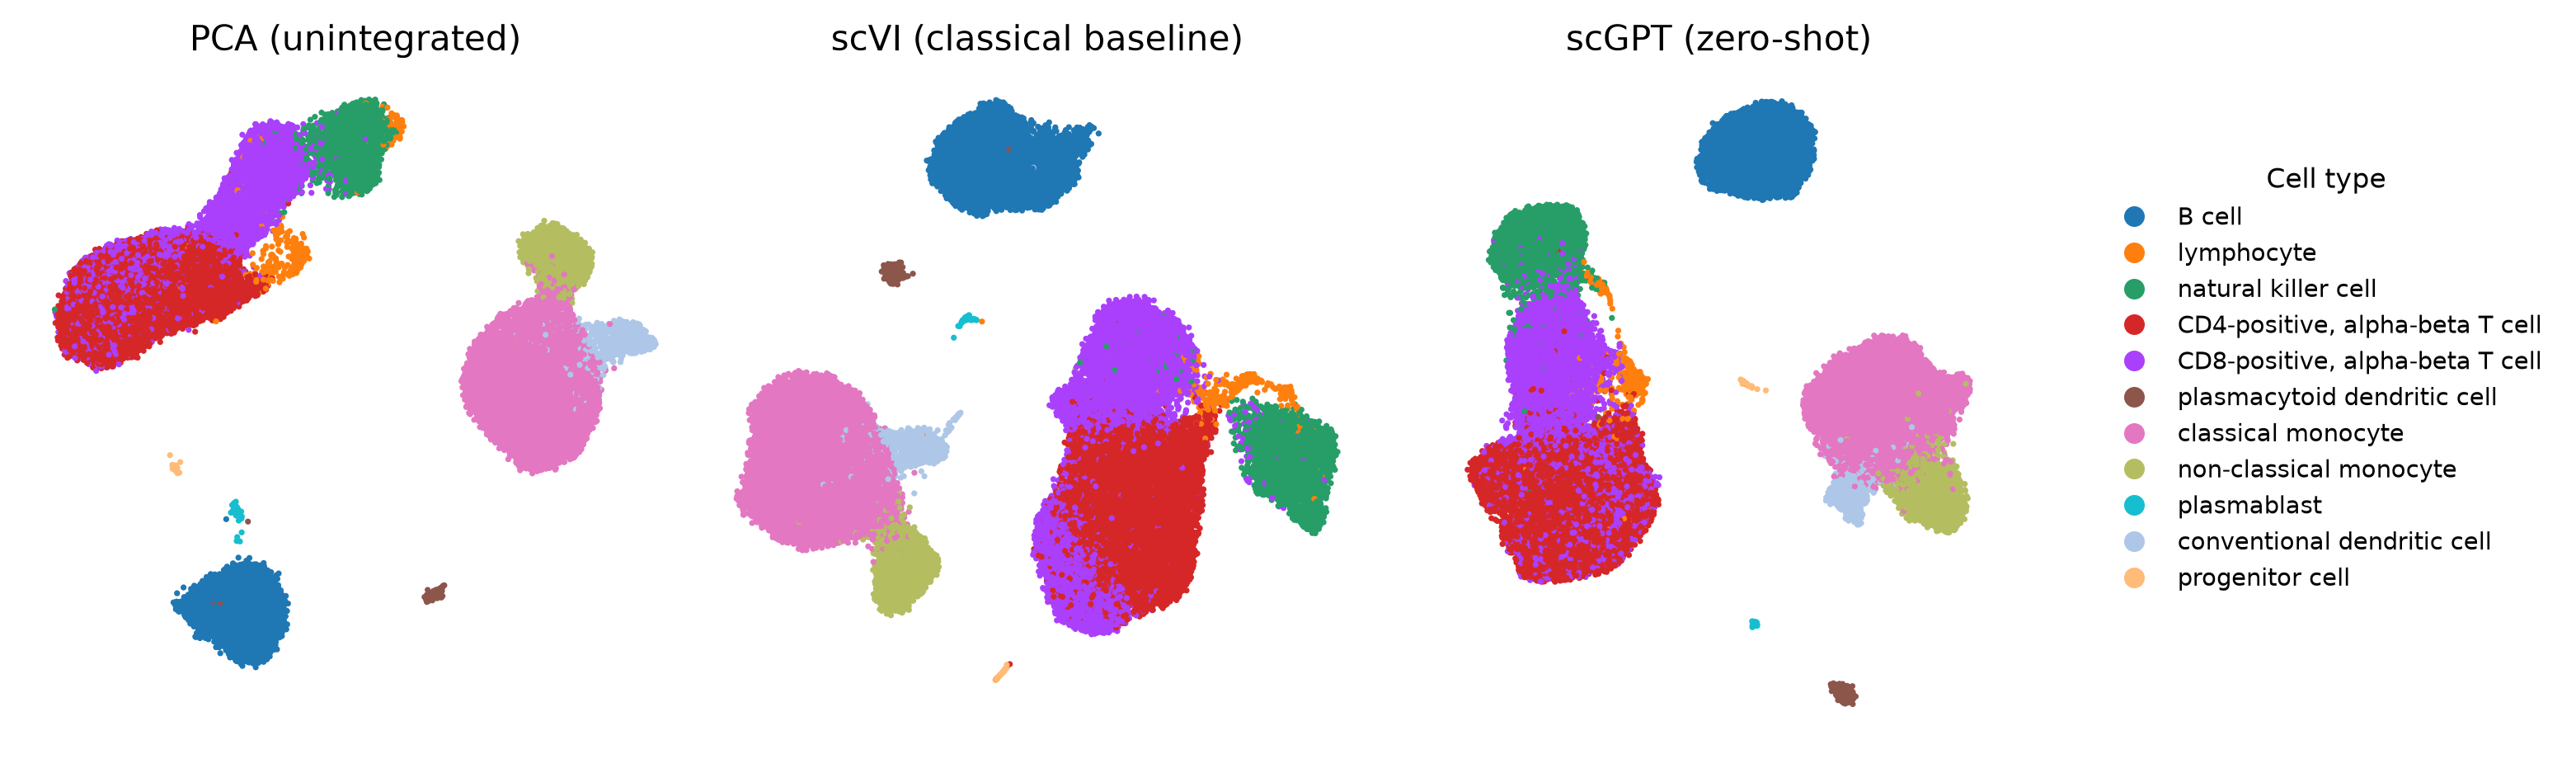

In [52]:

MM = 1 / 25.4
cell_type_key = "cell_type"
bases  = ["X_umap_pca", "X_umap_scvi", "X_umap_scgpt"]
titles = ["PCA (unintegrated)", "scVI (classical baseline)", "scGPT (zero-shot)"]

# Fixed category order + colors, shared across all three panels
if not pd.api.types.is_categorical_dtype(adata.obs[cell_type_key]):
    adata.obs[cell_type_key] = adata.obs[cell_type_key].astype("category")
sc.pl.embedding(adata, basis=bases[0], color=cell_type_key, show=False)
plt.close()  # just to populate adata.uns["cell_type_colors"] once

categories = adata.obs[cell_type_key].cat.categories
palette = dict(zip(categories, adata.uns[f"{cell_type_key}_colors"]))
point_colors = adata.obs[cell_type_key].map(palette).values

fig, axes = plt.subplots(
    1, 3, figsize=(210 * MM, 75 * MM), dpi=300,
    constrained_layout=True,   # handles spacing far more reliably than tight_layout here
)

for ax, basis, title in zip(axes, bases, titles):
    xy = adata.obsm[basis]
    ax.scatter(
        xy[:, 0], xy[:, 1],
        c=point_colors, s=3, linewidths=0,
        rasterized=True,
    )
    ax.set_title(title, fontsize=10)
    ax.set_aspect("equal", anchor="N")
    ax.axis("off")

# One shared legend
handles = [
    Line2D([0], [0], marker="o", linestyle="", markersize=5, color=palette[c])
    for c in categories
]
fig.legend(
    handles, categories,
    loc="center left", bbox_to_anchor=(1.02, 0.5),
    frameon=False, fontsize=7, title="Cell type", title_fontsize=8,
    borderaxespad=0,
)

fig.savefig( plots_dir / "umap_pca_scvi_scgpt.pdf", bbox_inches="tight")
plt.show()

In [53]:
embeddings = ["X_pca", "X_scVI", "X_scGPT"]
OFFICIAL = {"X_scVI": "classical baseline (a)", "X_scGPT": "foundation model (b)"}

labels = adata.obs["cell_type"].values
groups = adata.obs["donor_id"].values

gkf = GroupKFold(n_splits=5)
all_classes = np.unique(labels)
results = {}

for rep in embeddings:
    X = adata.obsm[rep]
    fold_metrics = []
    for fold_i, (train_idx, test_idx) in enumerate(gkf.split(X, labels, groups)):
        assert set(groups[train_idx]).isdisjoint(groups[test_idx]), "donor leaked across split!"

        scaler = StandardScaler().fit(X[train_idx])
        X_train, X_test = scaler.transform(X[train_idx]), scaler.transform(X[test_idx])
        y_train, y_test = labels[train_idx], labels[test_idx]

        missing = set(all_classes) - set(y_test)
        if missing:
            print(f"[{rep} fold {fold_i}] cell types absent from test set: {sorted(missing)}")

        clf = KNeighborsClassifier(n_neighbors=30)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)

        fold_metrics.append({
            "accuracy": accuracy_score(y_test, y_pred),
            "macro_f1": f1_score(y_test, y_pred, average="macro",
                                  labels=all_classes, zero_division=0),
            "report": classification_report(y_test, y_pred, labels=all_classes,
                                             output_dict=True, zero_division=0),
            "confusion_matrix": confusion_matrix(y_test, y_pred, labels=all_classes,
                                                  normalize="true"),
        })
    results[rep] = fold_metrics

In [54]:
for rep in embeddings:
    print(rep, adata.obsm[rep].shape)

X_pca (49444, 50)
X_scVI (49444, 10)
X_scGPT (49444, 512)


In [55]:
import pandas as pd

summary_rows = []
for rep, fold_metrics in results.items():
    accs = [f["accuracy"] for f in fold_metrics]
    f1s = [f["macro_f1"] for f in fold_metrics]
    summary_rows.append({
        "embedding": rep,
        "accuracy_mean": np.mean(accs),
        "accuracy_std": np.std(accs),
        "macro_f1_mean": np.mean(f1s),
        "macro_f1_std": np.std(f1s),
    })

summary_df = pd.DataFrame(summary_rows).set_index("embedding")
print(summary_df)

           accuracy_mean  accuracy_std  macro_f1_mean  macro_f1_std
embedding                                                          
X_pca           0.873288      0.003136       0.874599      0.008881
X_scVI          0.957850      0.001128       0.941277      0.006353
X_scGPT         0.926357      0.003183       0.922895      0.004332


In [56]:
per_class_rows = []
for rep, fold_metrics in results.items():
    for fold_i, f in enumerate(fold_metrics):
        report = f["report"]
        for class_name, metrics in report.items():
            if class_name in ("accuracy", "macro avg", "weighted avg"):
                continue
            per_class_rows.append({
                "embedding": rep,
                "fold": fold_i,
                "cell_type": class_name,
                "f1": metrics["f1-score"],
                "precision": metrics["precision"],
                "recall": metrics["recall"],
                "support": metrics["support"],
            })

per_class_df = pd.DataFrame(per_class_rows)

# average F1 per embedding x cell type across folds
per_class_pivot = (
    per_class_df.groupby(["cell_type", "embedding"])["f1"]
    .mean()
    .unstack("embedding")
    .sort_values(by=per_class_df["embedding"].unique()[0], ascending=False)
)
print(per_class_pivot)

embedding                           X_pca   X_scGPT    X_scVI
cell_type                                                    
plasmacytoid dendritic cell      0.992736  0.992184  0.990795
B cell                           0.992356  0.998896  0.999268
classical monocyte               0.978215  0.981999  0.987049
plasmablast                      0.977778  0.986667  0.964385
non-classical monocyte           0.957509  0.931085  0.953039
conventional dendritic cell      0.905937  0.865355  0.893583
natural killer cell              0.849687  0.955708  0.969864
CD4-positive, alpha-beta T cell  0.830836  0.908305  0.948134
lymphocyte                       0.758211  0.769475  0.813783
CD8-positive, alpha-beta T cell  0.703904  0.826405  0.914625
progenitor cell                  0.673424  0.935766  0.919527


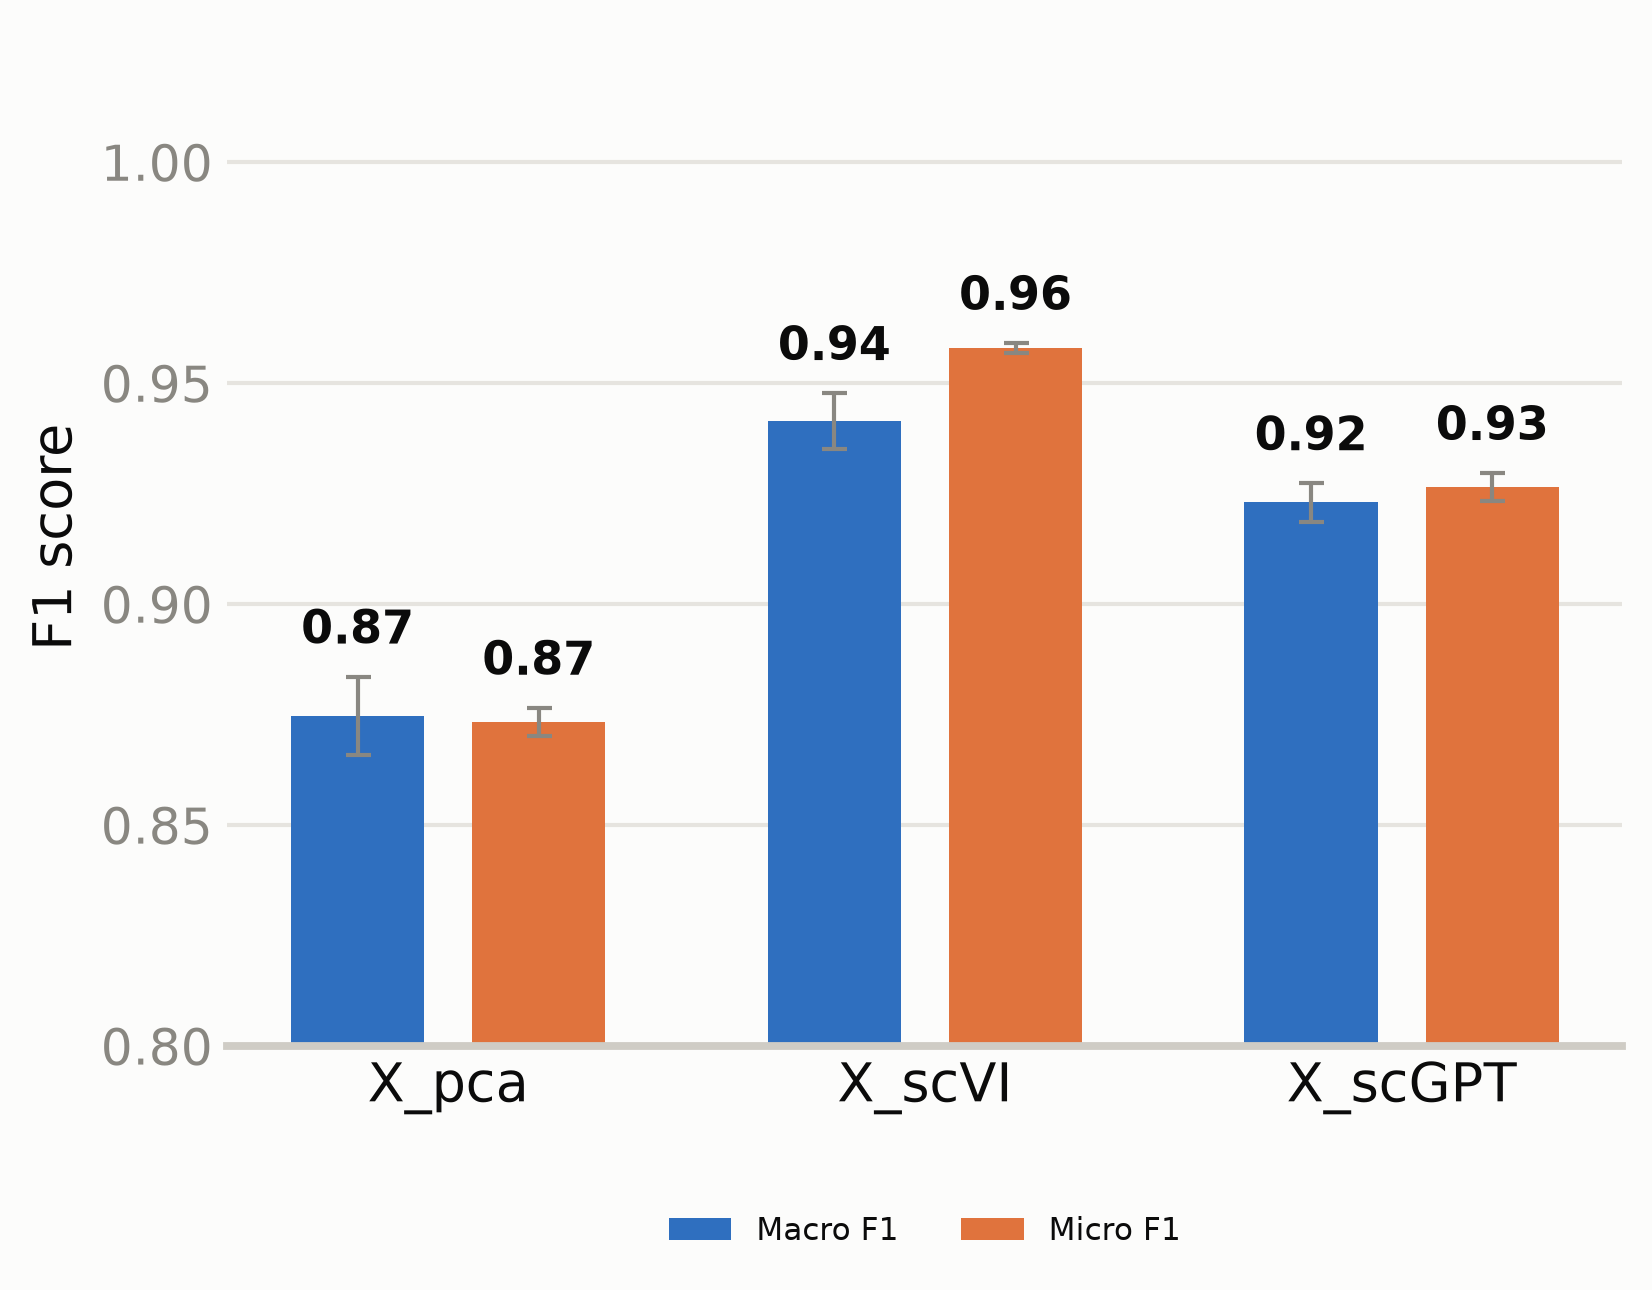

In [57]:
# --- style constants ---
SURFACE = "#fcfcfb"
COLOR_TEXT_PRIMARY = "#0b0b0b"
COLOR_TEXT_MUTED = "#898781"
COLOR_GRID = "#e6e4df"
COLOR_AXIS = "#cfccc5"
COLOR_MACRO = "#2f6fbf"   # blue
COLOR_MICRO = "#e0733d"   # orange


# --- data ---
embeddings = list(summary_df.index)   # ["X_pca", "X_scVI", "X_scGPT"]
x = np.arange(len(embeddings))
bar_w, gap = 0.28, 0.10


def _annotate_bars(ax, bars, errs):
    """Print each bar's height above its error whisker."""
    for rect, err in zip(bars, errs):
        h = rect.get_height()
        ax.text(
            rect.get_x() + rect.get_width() / 2, h + err + 0.005,
            f"{h:.2f}", ha="center", va="bottom",
            fontsize=11, fontweight="bold", color=COLOR_TEXT_PRIMARY,
        )


# --- figure ---
fig, ax = plt.subplots(figsize=(6, 4.4), dpi=300)
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

bars_macro = ax.bar(
    x - (bar_w + gap) / 2, summary_df["macro_f1_mean"], width=bar_w,
    yerr=summary_df["macro_f1_std"], capsize=3,
    color=COLOR_MACRO, edgecolor="none",
    error_kw=dict(ecolor=COLOR_TEXT_MUTED, elinewidth=1, capthick=1),
    label="Macro F1",
)
bars_micro = ax.bar(
    x + (bar_w + gap) / 2, summary_df["accuracy_mean"], width=bar_w,
    yerr=summary_df["accuracy_std"], capsize=3,
    color=COLOR_MICRO, edgecolor="none",
    error_kw=dict(ecolor=COLOR_TEXT_MUTED, elinewidth=1, capthick=1),
    label="Micro F1",
)

_annotate_bars(ax, bars_macro, summary_df["macro_f1_std"])
_annotate_bars(ax, bars_micro, summary_df["accuracy_std"])

# --- styling ---
ax.yaxis.grid(True, color=COLOR_GRID, linewidth=1)
ax.set_axisbelow(True)
for spine in ("top", "right", "left"):
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(COLOR_AXIS)

ax.set_xticks(x)
ax.set_xticklabels(embeddings, color=COLOR_TEXT_PRIMARY, fontsize=13)

ax.set_ylim(0.8, 1.03)
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.05))
ax.tick_params(axis="y", colors=COLOR_TEXT_MUTED, length=0, labelsize=12)
ax.tick_params(axis="x", length=0)
ax.set_ylabel("F1 score", color=COLOR_TEXT_PRIMARY, fontsize=13)

ax.legend(
    frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.14),
    ncol=2, fontsize=7.5, labelcolor=COLOR_TEXT_PRIMARY,
)

# --- save ---
fig.savefig(
    plots_dir / "embedding_f1_barplot.png",
    facecolor=fig.get_facecolor(), bbox_inches="tight",
)
plt.show()

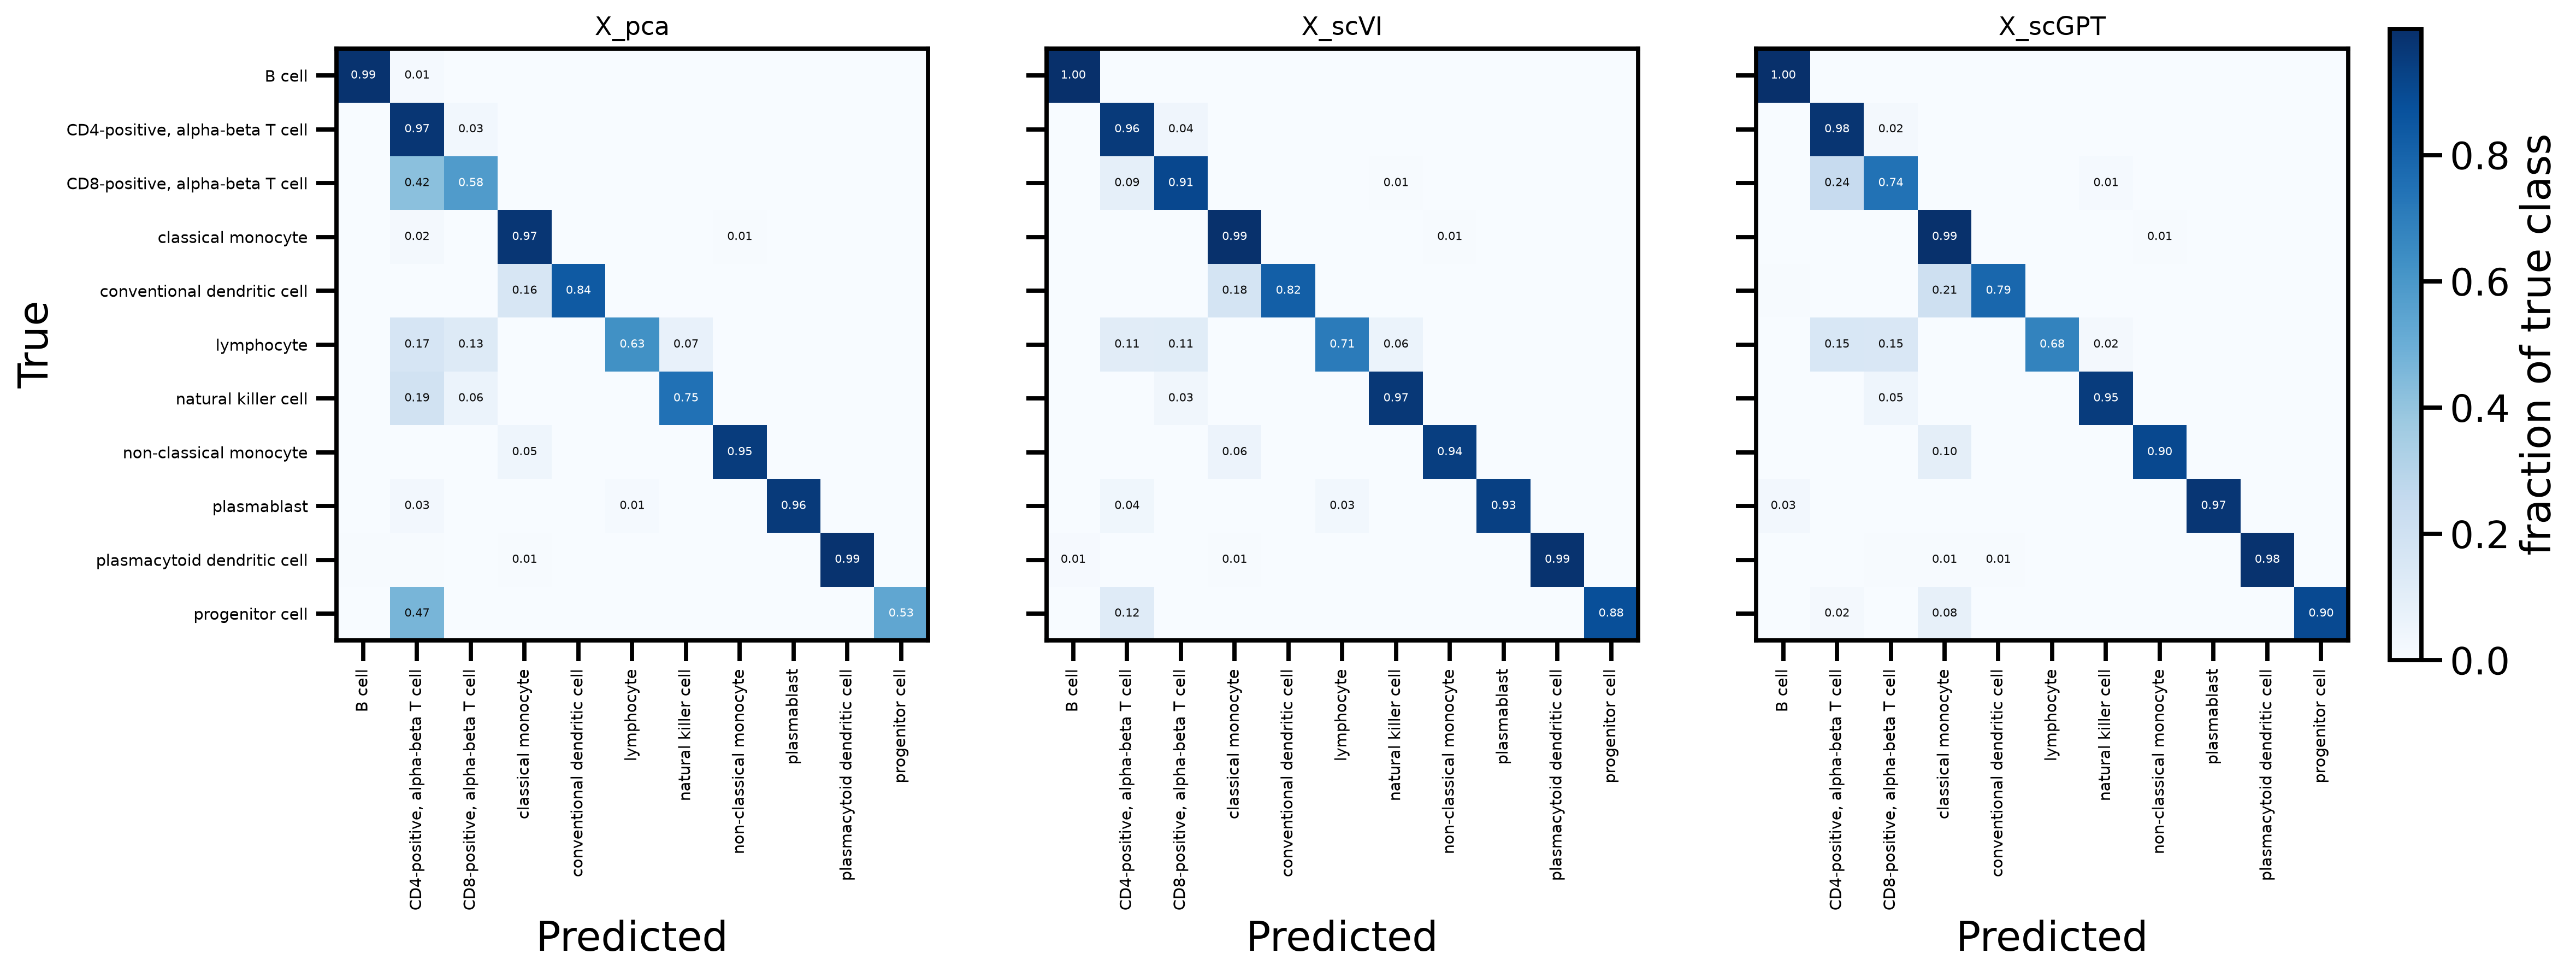

In [58]:
mean_cms = {}
for rep in embeddings:
    cms = np.stack([f["confusion_matrix"] for f in results[rep]])
    mean_cms[rep] = cms.mean(axis=0)

all_vals = np.concatenate([m.ravel() for m in mean_cms.values()])
norm = Normalize(vmin=all_vals.min(), vmax=all_vals.max())
cmap = mpl.colormaps["Blues"]

def _text_color(val):
    r, g, b, _ = cmap(norm(val))
    luminance = 0.299 * r + 0.587 * g + 0.114 * b
    return "#ffffff" if luminance < 0.6 else "#0b0b0b"

fig, axes = plt.subplots(1, len(embeddings), figsize=(5.5 * len(embeddings), 5), dpi=300)
if len(embeddings) == 1:
    axes = [axes]

for ax, rep in zip(axes, embeddings):
    mat = mean_cms[rep]
    im = ax.imshow(mat, cmap=cmap, norm=norm)

    n_rows, n_cols = mat.shape
    for i in range(n_rows):
        for j in range(n_cols):
            val = mat[i, j]
            label = f"{val:.2f}"
            if label != "0.00":
                ax.text(j, i, label, ha="center", va="center",
                         fontsize=5, color=_text_color(val))

    ax.set_xticks(range(len(all_classes)))
    ax.set_xticklabels(all_classes, rotation=90, fontsize=7)
    ax.set_yticks(range(len(all_classes)))

    if ax is axes[0]:
        ax.set_yticklabels(all_classes, fontsize=7)
        ax.set_ylabel("True")
    else:
        ax.set_yticklabels([])  # keep tick marks, drop the text labels

    ax.set_title(rep, fontsize=11)
    ax.set_xlabel("Predicted")

fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02, label="fraction of true class")
fig.savefig(plots_dir / "confusion_matrices.png",
dpi=300, bbox_inches="tight")
plt.show()